# Bounding Box Annotation Examples

This notebook visualizes representative lesion annotations from the dataset. It automatically selects:

- one **very small** lesion annotation
- one **very large** lesion annotation
- one image containing **multiple lesions in the same image**

Each example is displayed with its bounding boxes and class annotations, and the small/large examples also include zoomed-in views.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import csv

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image


def resolve_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "medical_detection").exists():
            return candidate
    raise FileNotFoundError("Could not locate a project root containing the medical_detection package.")


@dataclass(frozen=True)
class AnnotationRecord:
    class_id: int
    x_center: float
    y_center: float
    width: float
    height: float


@dataclass(frozen=True)
class ImageRecord:
    image_path: Path
    label_path: Path
    annotations: tuple[AnnotationRecord, ...]

    @property
    def filename(self) -> str:
        return self.image_path.name


@dataclass(frozen=True)
class ProjectPaths:
    project_root: Path
    dataset_root: Path

    @property
    def image_dir(self) -> Path:
        return self.dataset_root / "SEE_AI_project_all_images" / "SEE_AI_project_all_images"

    @property
    def label_dir(self) -> Path:
        return self.dataset_root / "SEE_AI_project_all_txt" / "SEE_AI_project_all_txt"

    @property
    def csv_path(self) -> Path:
        return self.dataset_root / "all_annotation.csv"


def resolve_dataset_root(project_root: Path) -> Path:
    kaggle_candidate = Path("/kaggle/input/datasets/capsuleyolo/kyucapsule")
    if kaggle_candidate.exists():
        return kaggle_candidate
    return project_root


def class_names_from_csv(csv_path: Path) -> list[str]:
    class_mapping: dict[int, str] = {}
    with csv_path.open("r", encoding="utf-8") as handle:
        reader = csv.reader(handle)
        class_names_row = next(reader)
        class_ids_row = next(reader)
        for name, class_id_str in zip(class_names_row, class_ids_row):
            value = class_id_str.strip()
            if value.isdigit():
                class_mapping[int(value)] = name.strip()
    max_class_id = max(class_mapping)
    return [class_mapping.get(index, f"missing_class_{index}") for index in range(max_class_id + 1)]


def parse_annotation_line(line: str) -> AnnotationRecord | None:
    parts = line.strip().split()
    if len(parts) != 5:
        return None
    class_id = int(float(parts[0]))
    x_center, y_center, width, height = map(float, parts[1:])
    if not (0.0 <= x_center <= 1.0 and 0.0 <= y_center <= 1.0):
        return None
    if not (0.0 < width <= 1.0 and 0.0 < height <= 1.0):
        return None
    return AnnotationRecord(class_id=class_id, x_center=x_center, y_center=y_center, width=width, height=height)


def read_label_file(label_path: Path) -> tuple[AnnotationRecord, ...]:
    if not label_path.exists():
        return ()
    annotations = []
    with label_path.open("r", encoding="utf-8") as handle:
        for line in handle:
            annotation = parse_annotation_line(line)
            if annotation is not None:
                annotations.append(annotation)
    return tuple(annotations)


def build_dataset_index(image_dir: Path, label_dir: Path) -> list[ImageRecord]:
    image_paths = []
    for pattern in ("*.jpg", "*.jpeg", "*.png"):
        image_paths.extend(sorted(image_dir.rglob(pattern)))
    records = []
    for image_path in sorted(image_paths):
        label_path = label_dir / f"{image_path.stem}.txt"
        records.append(ImageRecord(image_path=image_path, label_path=label_path, annotations=read_label_file(label_path)))
    return records


def convert_yolo_to_xyxy(x_center, y_center, box_width, box_height, image_width, image_height):
    xmin = max(0.0, (x_center - box_width / 2.0) * float(image_width))
    ymin = max(0.0, (y_center - box_height / 2.0) * float(image_height))
    xmax = min(float(image_width), (x_center + box_width / 2.0) * float(image_width))
    ymax = min(float(image_height), (y_center + box_height / 2.0) * float(image_height))
    if xmax <= xmin:
        xmax = min(float(image_width), xmin + 1.0)
    if ymax <= ymin:
        ymax = min(float(image_height), ymin + 1.0)
    return xmin, ymin, xmax, ymax


PROJECT_ROOT = resolve_project_root(Path.cwd())
DATASET_ROOT = resolve_dataset_root(PROJECT_ROOT)
paths = ProjectPaths(project_root=PROJECT_ROOT, dataset_root=DATASET_ROOT)
records = build_dataset_index(paths.image_dir, paths.label_dir)
class_names = class_names_from_csv(paths.csv_path)


def annotation_area_ratio(annotation) -> float:
    return float(annotation.width * annotation.height)


def load_image_size(image_path: Path) -> tuple[int, int]:
    with Image.open(image_path) as image_handle:
        return image_handle.size


def build_annotation_rows(records) -> pd.DataFrame:
    rows = []
    for record in records:
        image_width, image_height = load_image_size(record.image_path)
        for annotation_index, annotation in enumerate(record.annotations):
            xmin, ymin, xmax, ymax = convert_yolo_to_xyxy(
                annotation.x_center,
                annotation.y_center,
                annotation.width,
                annotation.height,
                image_width,
                image_height,
            )
            rows.append(
                {
                    "record": record,
                    "image_name": record.filename,
                    "annotation_index": annotation_index,
                    "class_id": annotation.class_id,
                    "class_name": class_names[annotation.class_id],
                    "annotation_count": len(record.annotations),
                    "image_width": image_width,
                    "image_height": image_height,
                    "area_ratio": annotation_area_ratio(annotation),
                    "pixel_area": float((xmax - xmin) * (ymax - ymin)),
                    "box_width_px": float(xmax - xmin),
                    "box_height_px": float(ymax - ymin),
                }
            )
    return pd.DataFrame(rows)


def pick_row(frame: pd.DataFrame, excluded_images: set[str], ascending: bool) -> pd.Series:
    candidate_frame = frame[~frame["image_name"].isin(excluded_images)]
    if candidate_frame.empty:
        candidate_frame = frame
    ordered = candidate_frame.sort_values(
        ["area_ratio", "pixel_area", "image_name", "annotation_index"],
        ascending=[ascending, ascending, True, True],
        ignore_index=True,
    )
    return ordered.iloc[0]


positive_records = [record for record in records if record.annotations]
annotation_rows = build_annotation_rows(positive_records)
used_images: set[str] = set()

small_example = pick_row(annotation_rows, excluded_images=used_images, ascending=True)
used_images.add(small_example["image_name"])

big_example = pick_row(annotation_rows, excluded_images=used_images, ascending=False)
used_images.add(big_example["image_name"])

multi_candidates = [record for record in positive_records if len(record.annotations) >= 2 and record.filename not in used_images]
if not multi_candidates:
    multi_candidates = [record for record in positive_records if len(record.annotations) >= 2]
if not multi_candidates:
    raise ValueError("No image with multiple annotations was found in the dataset.")

multi_record = max(
    multi_candidates,
    key=lambda record: (
        len(record.annotations),
        sum(annotation_area_ratio(annotation) for annotation in record.annotations),
        record.filename,
    ),
)


def annotation_box(record, annotation_index: int):
    image_width, image_height = load_image_size(record.image_path)
    annotation = record.annotations[annotation_index]
    return convert_yolo_to_xyxy(
        annotation.x_center,
        annotation.y_center,
        annotation.width,
        annotation.height,
        image_width,
        image_height,
    )


def summarize_example(category: str, row: pd.Series | None = None, record=None) -> dict:
    if row is not None:
        return {
            "category": category,
            "image_name": row["image_name"],
            "class_name": row["class_name"],
            "annotation_count": int(row["annotation_count"]),
            "image_size": f"{int(row['image_width'])}x{int(row['image_height'])}",
            "box_area_pct": round(float(row["area_ratio"]) * 100.0, 4),
            "box_size_px": f"{int(round(row['box_width_px']))}x{int(round(row['box_height_px']))}",
        }
    classes = sorted({class_names[annotation.class_id] for annotation in record.annotations})
    image_width, image_height = load_image_size(record.image_path)
    return {
        "category": category,
        "image_name": record.filename,
        "class_name": ", ".join(classes),
        "annotation_count": len(record.annotations),
        "image_size": f"{image_width}x{image_height}",
        "box_area_pct": None,
        "box_size_px": "multiple",
    }


summary_df = pd.DataFrame(
    [
        summarize_example("Very small lesion", row=small_example),
        summarize_example("Very large lesion", row=big_example),
        summarize_example("Multiple lesions in one image", record=multi_record),
    ]
)

summary_df


,category,image_name,class_name,annotation_count,image_size,box_area_pct,box_size_px
0,Very small lesion,image10338.jpg,lymph follicle,19,576x576,0.0759,10x25
1,Very large lesion,image07996.jpg,erythema,1,576x576,92.4995,553x555
2,Multiple lesions in one image,image01623.jpg,foreign body,45,576x576,NaN,multiple


In [2]:
summary_df


,category,image_name,class_name,annotation_count,image_size,box_area_pct,box_size_px
0,Very small lesion,image10338.jpg,lymph follicle,19,576x576,0.0759,10x25
1,Very large lesion,image07996.jpg,erythema,1,576x576,92.4995,553x555
2,Multiple lesions in one image,image01623.jpg,foreign body,45,576x576,NaN,multiple


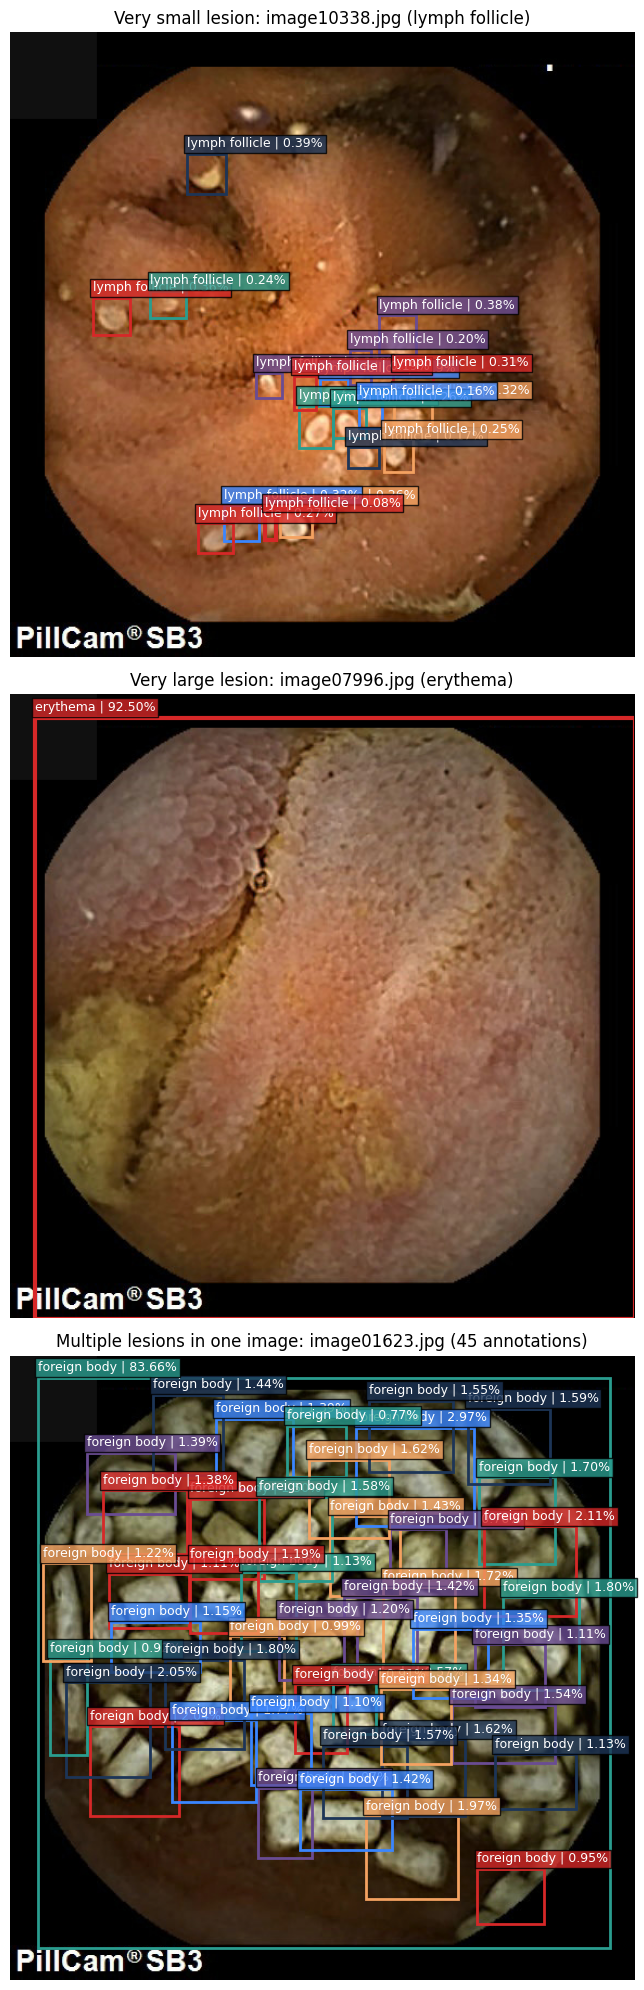

In [3]:
def draw_record(ax, record, title: str, highlight_annotation_index: int | None = None) -> None:
    with Image.open(record.image_path) as image_handle:
        image = image_handle.convert("RGB")
        image_width, image_height = image.size

    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

    palette = ["#d62828", "#1d3557", "#2a9d8f", "#6a4c93", "#f4a261", "#3a86ff"]

    for annotation_index, annotation in enumerate(record.annotations):
        xmin, ymin, xmax, ymax = convert_yolo_to_xyxy(
            annotation.x_center,
            annotation.y_center,
            annotation.width,
            annotation.height,
            image_width,
            image_height,
        )
        is_highlight = highlight_annotation_index is not None and annotation_index == highlight_annotation_index
        color = "#d62828" if is_highlight else palette[annotation_index % len(palette)]
        linewidth = 3 if is_highlight else 2
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=linewidth,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)
        label = f"{class_names[annotation.class_id]} | {annotation.width * annotation.height * 100:.2f}%"
        ax.text(
            xmin,
            max(0, ymin - 6),
            label,
            color="white",
            fontsize=9,
            bbox={"facecolor": color, "alpha": 0.8, "pad": 2},
        )


fig, axes = plt.subplots(3, 1, figsize=(14, 20))

draw_record(
    axes[0],
    small_example["record"],
    title=f"Very small lesion: {small_example['image_name']} ({small_example['class_name']})",
    highlight_annotation_index=int(small_example["annotation_index"]),
)
draw_record(
    axes[1],
    big_example["record"],
    title=f"Very large lesion: {big_example['image_name']} ({big_example['class_name']})",
    highlight_annotation_index=int(big_example["annotation_index"]),
)
draw_record(
    axes[2],
    multi_record,
    title=f"Multiple lesions in one image: {multi_record.filename} ({len(multi_record.annotations)} annotations)",
    highlight_annotation_index=None,
)

plt.tight_layout()
plt.show()


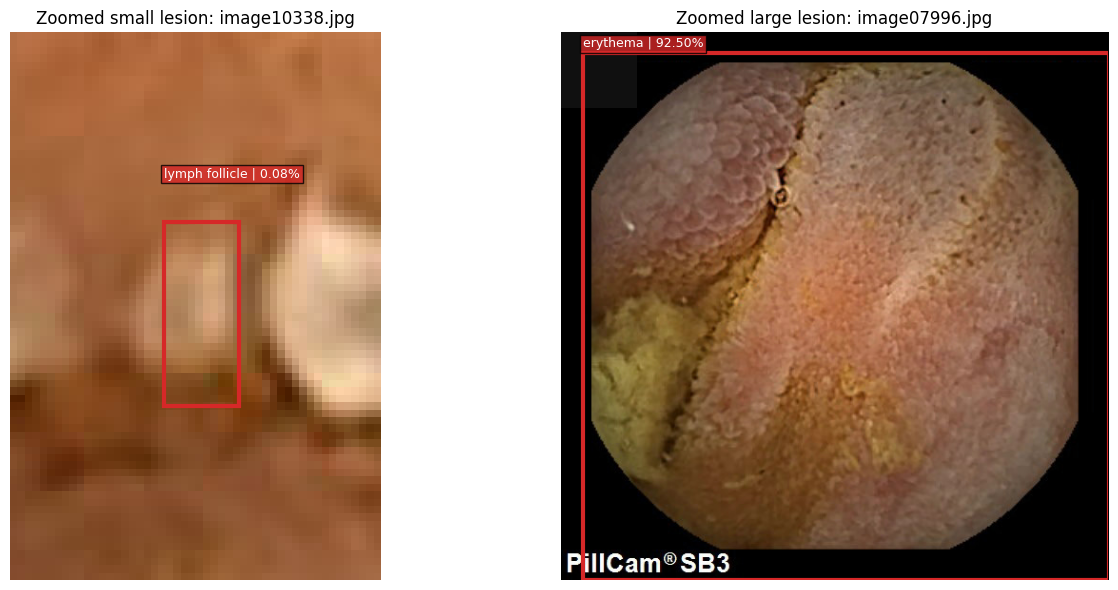

In [4]:
def draw_zoomed_annotation(ax, record, annotation_index: int, title: str, padding_ratio: float = 0.35) -> None:
    with Image.open(record.image_path) as image_handle:
        image = image_handle.convert("RGB")
        image_width, image_height = image.size

    annotation = record.annotations[annotation_index]
    xmin, ymin, xmax, ymax = convert_yolo_to_xyxy(
        annotation.x_center,
        annotation.y_center,
        annotation.width,
        annotation.height,
        image_width,
        image_height,
    )

    box_width = xmax - xmin
    box_height = ymax - ymin
    pad_x = max(20.0, box_width * padding_ratio)
    pad_y = max(20.0, box_height * padding_ratio)

    crop_xmin = max(0, int(xmin - pad_x))
    crop_ymin = max(0, int(ymin - pad_y))
    crop_xmax = min(image_width, int(xmax + pad_x))
    crop_ymax = min(image_height, int(ymax + pad_y))

    crop = image.crop((crop_xmin, crop_ymin, crop_xmax, crop_ymax))
    ax.imshow(crop)
    ax.set_title(title)
    ax.axis("off")

    rect = patches.Rectangle(
        (xmin - crop_xmin, ymin - crop_ymin),
        box_width,
        box_height,
        linewidth=3,
        edgecolor="#d62828",
        facecolor="none",
    )
    ax.add_patch(rect)
    ax.text(
        max(0, xmin - crop_xmin),
        max(0, ymin - crop_ymin - 6),
        f"{class_names[annotation.class_id]} | {annotation.width * annotation.height * 100:.2f}%",
        color="white",
        fontsize=9,
        bbox={"facecolor": "#d62828", "alpha": 0.8, "pad": 2},
    )


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
draw_zoomed_annotation(
    axes[0],
    small_example["record"],
    int(small_example["annotation_index"]),
    title=f"Zoomed small lesion: {small_example['image_name']}",
    padding_ratio=1.0,
)
draw_zoomed_annotation(
    axes[1],
    big_example["record"],
    int(big_example["annotation_index"]),
    title=f"Zoomed large lesion: {big_example['image_name']}",
    padding_ratio=0.2,
)
plt.tight_layout()
plt.show()
